In [ ]:
#| hide
from programming_first_principles.core import prepare_notebook
from programming_first_principles.predicates import amounts_sum_to
from programming_first_principles.helpers import Cost
from collections import namedtuple
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#| hide
prepare_notebook()

## Complexity/Cost Analysis

In [ ]:
#| hide 
#| default_exp accumulate

#### Linear - Sum

In [ ]:
#| exports
def c_sum(nums):
  sum = 0
  for num in nums:
    sum += num
  return sum

In [ ]:
# nums = [random.randint(1, 10000) for _ in range(10000)]
nums = [7,4,2,3,17,18]
f'{c_sum(nums) = }'
f'{sum(nums) = }'

'c_sum(nums) = 51'

'sum(nums) = 51'

In [ ]:
linear = Cost(repeats=5)
for n in (5_000, 10_000, 20_000):
    _ = linear.run(c_sum, [1] * n)
linear.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,c_sum,,5000,None,None,None,0.1284
1,c_sum,,10000,None,None,None,0.3964
2,c_sum,,20000,None,None,None,0.6240


#### Linear - min
* Iterator - Walk the sequence
* Assume first one is min.
* Compare and swap min if predicate is true
* Check how many comparison happened

In [ ]:
#| exports
def c_min(seq):
  #Iterator to walk over the sequence
  it = iter(seq)
  # Assume first element as min
  winner = next(it)
  # walk over rest to compare
  for val in it:
    if val < winner:
      winner = val
  return winner

In [ ]:
f'{c_min(nums) = }'
f'{min(nums) = }'

'c_min(nums) = 2'

'min(nums) = 2'

In [ ]:
min_linear = Cost(repeats=5)
_ = min_linear.scale(
    c_min,
    args=lambda data: (),
    sizes=(5_000, 10_000, 20_000),
    operations=('comparisons', 'ms'),
)
min_linear.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,c_min,random,5000,4999,None,None,0.0829
1,c_min,sorted,5000,4999,None,None,0.0991
2,c_min,reversed,5000,4999,None,None,0.1746
3,c_min,random,10000,9999,None,None,0.1911
4,c_min,sorted,10000,9999,None,None,0.2286
5,c_min,reversed,10000,9999,None,None,0.4131
6,c_min,random,20000,19999,None,None,0.2840
7,c_min,sorted,20000,19999,None,None,0.3509
8,c_min,reversed,20000,19999,None,None,0.6464


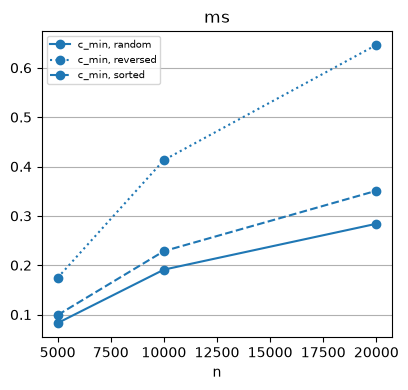

In [ ]:
min_linear.plot('ms')

#### Linear - max
* Iterator - Walk the sequence
* Assume first one is max.
* Compare and swap max if predicate is true
* Check how many comparison happened

In [ ]:
#| exports
def c_max(seq):
  #Iterator to walk over the sequence
  it = iter(seq)
  # Assume first element as min
  winner = next(it)
  # walk over rest to compare
  for val in it:
    if not val < winner:
      winner = val
  return winner

In [ ]:
f'{c_max(nums) = }'
f'{max(nums) = }'

'c_max(nums) = 18'

'max(nums) = 18'

In [ ]:
max_linear = Cost(repeats=5)
_ = max_linear.scale(
    c_max,
    args=lambda data: (),
    sizes=(5_000, 10_000, 20_000),
    operations=('comparisons', 'ms'),
)
max_linear.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,c_max,random,5000,4999,None,None,0.1217
1,c_max,sorted,5000,4999,None,None,0.1021
2,c_max,reversed,5000,4999,None,None,0.1090
3,c_max,random,10000,9999,None,None,0.1618
4,c_max,sorted,10000,9999,None,None,0.2918
5,c_max,reversed,10000,9999,None,None,0.1572
6,c_max,random,20000,19999,None,None,0.3451
7,c_max,sorted,20000,19999,None,None,0.5783
8,c_max,reversed,20000,19999,None,None,0.3208


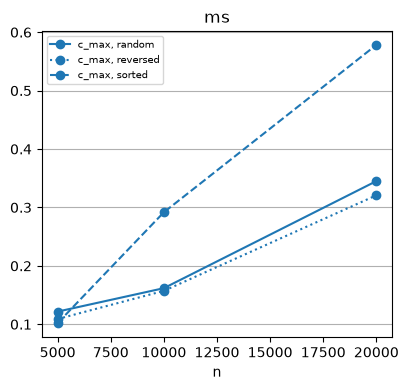

In [ ]:
max_linear.plot('ms')

#### Quadratic - 2 Sum

In [ ]:
#| exports
from programming_first_principles.predicates import sums_to
def find_2sum(a, T, pred=sums_to):
    for x in a:
        for y in a:
            if pred(x, y, T=T):
                return x, y
    return None, None

In [ ]:
find_2sum(a=[1.5, 2.5, 4.0], T=4.0)

(1.5, 2.5)

In [ ]:
Txn = namedtuple("Txn", ["id", "amount"])

txns = [
    Txn("TXN1001", 4200),
    Txn("TXN1002", 1500),
    Txn("TXN1003", 9800),
    Txn("TXN1004", 3300),
    Txn("TXN1005", 2700),
]
T = 10_000

f'Worst Case: {find_2sum(txns,T,amounts_sum_to) = }'

'Worst Case: find_2sum(txns,T,amounts_sum_to) = (None, None)'

In [ ]:
txns.append(Txn("TXN1006", 5800))
f'Best Case: {find_2sum(txns,T,amounts_sum_to) = }'

"Best Case: find_2sum(txns,T,amounts_sum_to) = (Txn(id='TXN1001', amount=4200), Txn(id='TXN1006', amount=5800))"

#### Quadratic - 3 Sum

In [ ]:
#| exports
from programming_first_principles.predicates import sums_to
def find_3sum(a, T, pred=sums_to):
    for x in a:
        for y in a:
            for z in a:
                if pred(x, y, z, T=T):
                    return x, y, z
    return None, None, None

In [ ]:
txns_1 = [
    Txn("TXN1001", 4200),
    Txn("TXN1002", 1500),
    Txn("TXN1003", 9800),
    Txn("TXN1004", 3300),
    Txn("TXN1005", 2700),
    Txn("TXN1006", 1000),
]
T = 9200
f'{find_3sum(txns_1, T=T,pred=amounts_sum_to) = }'

'find_3sum(txns_1, T=T,pred=amounts_sum_to) = (None, None, None)'

In [ ]:
txns_1.append(Txn("TXN1007", 1700))
f'{find_3sum(txns_1, T=T,pred=amounts_sum_to) = }'

"find_3sum(txns_1, T=T,pred=amounts_sum_to) = (Txn(id='TXN1001', amount=4200), Txn(id='TXN1004', amount=3300), Txn(id='TXN1007', amount=1700))"

In [ ]:
def many_txns(n):
    return [Txn(f"TXN{i}", 100 + i) for i in range(n)]

timed = Cost(repeats=1)

for n in (40, 80):
    _ = timed.run(find_2sum, many_txns(n), 0, amounts_sum_to,
              operations=('predicates', 'ms'), shape='worst')

In [ ]:
timed.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,find_2sum,worst,40,None,1600,None,0.8949
1,find_2sum,worst,80,None,6400,None,2.8080


In [ ]:
for n in (40, 80):
    _ = timed.run(find_3sum, many_txns(n), 0, amounts_sum_to,
              operations=('predicates', 'ms'), shape='worst')

In [ ]:
timed.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,find_2sum,worst,40,None,1600,None,0.8949
1,find_2sum,worst,80,None,6400,None,2.8080
2,find_3sum,worst,40,None,64000,None,58.3476
3,find_3sum,worst,80,None,512000,None,243.7737


#### Plot
* Linear, Quadratic, Cubic, Logarithm

[<matplotlib.lines.Line2D>]

Text(0.5, 1.0, 'linear')

[<matplotlib.lines.Line2D>]

Text(0.5, 1.0, 'quadratic')

[<matplotlib.lines.Line2D>]

...

<matplotlib.legend.Legend>

Text(0.5, 0, 'n')

<matplotlib.legend.Legend>

Text(0.5, 0, 'n')

<matplotlib.legend.Legend>

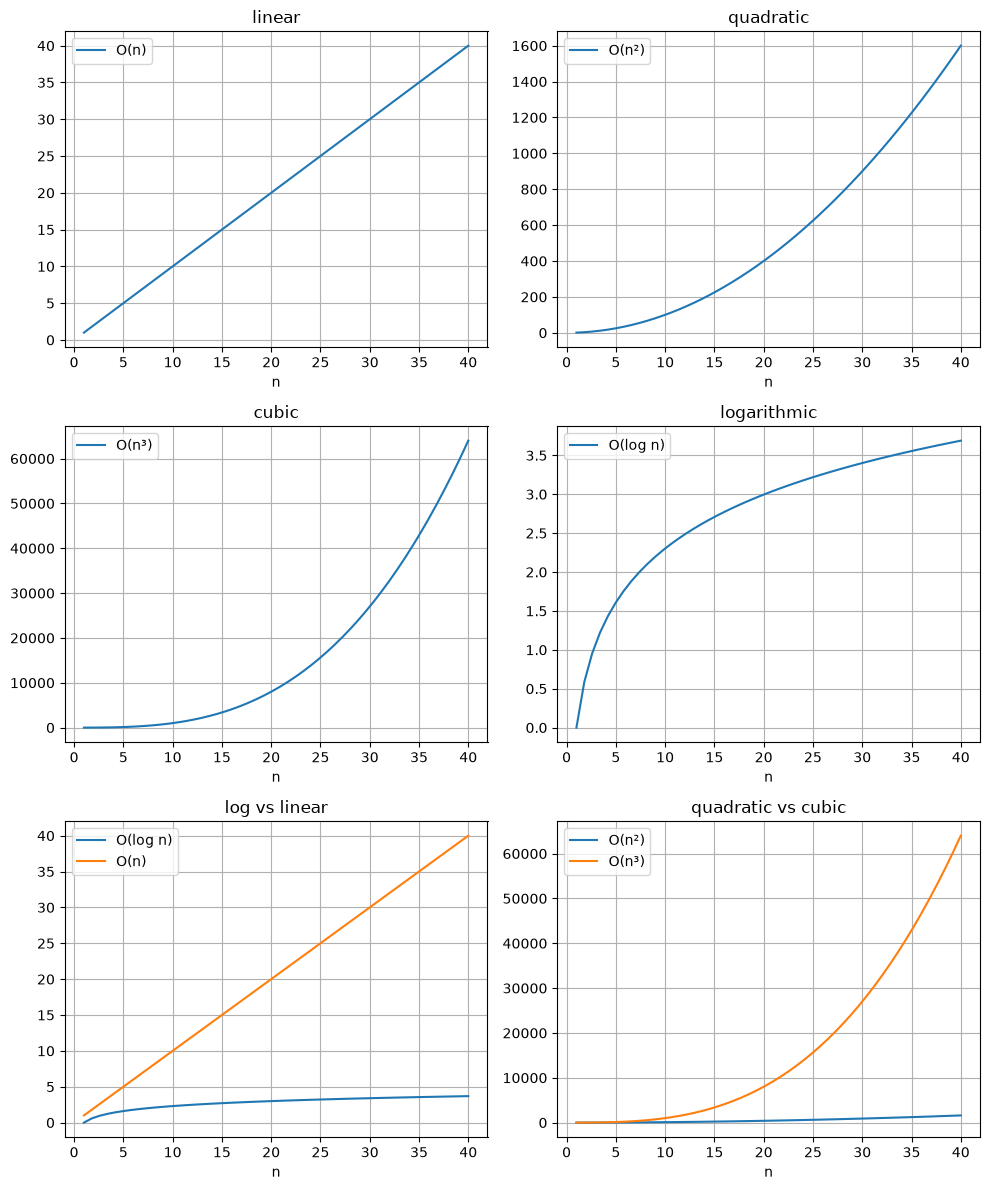

In [ ]:
ns = np.linspace(1, 40, 50)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

axes[0, 0].plot(ns, ns, label="O(n)")
axes[0, 0].set_title("linear")

axes[0, 1].plot(ns, ns**2, label="O(n²)")
axes[0, 1].set_title("quadratic")

axes[1, 0].plot(ns, ns**3, label="O(n³)")
axes[1, 0].set_title("cubic")

axes[1, 1].plot(ns, np.log(ns), label="O(log n)")
axes[1, 1].set_title("logarithmic")

axes[2, 0].plot(ns, np.log(ns), label="O(log n)")
axes[2, 0].plot(ns, ns, label="O(n)")
axes[2, 0].set_title("log vs linear")

axes[2, 1].plot(ns, ns**2, label="O(n²)")
axes[2, 1].plot(ns, ns**3, label="O(n³)")
axes[2, 1].set_title("quadratic vs cubic")

for row in axes:
    for ax in row:
        ax.set_xlabel("n")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()